# Single-scale sampler: first verification on NIST

Before running the sampler on EMPS, verify it on the NIST fixture: one
clean reference image with a controlled, simple geometry. If the sampler
cannot produce plausible structure here, there is a bug in the pipeline,
not a research finding.


## 1. Load the NIST clean reference

loaded NIST clean reference: full shape=(512, 512)
using a 64x64 crop for this CPU verification: shape=(64, 64)


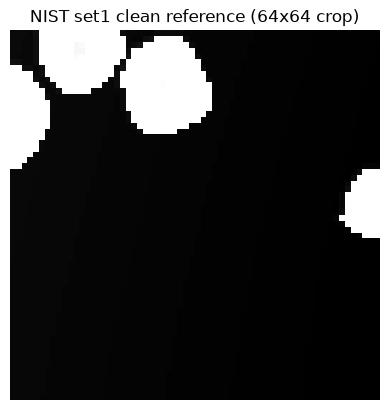

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

NIST_DIR = os.path.join("..", "..", "..", "AMAT", "nist_detection_limits_sem")
clean_path = os.path.join(NIST_DIR, "mask_sets", "masks", "set1_cex_noise_000_contrast_100.tiff")

full_image = np.array(Image.open(clean_path)).astype(np.float64)
print(f"loaded NIST clean reference: full shape={full_image.shape}")

# CPU sanity check: use a small crop, not the full image - the sampler is
# O(patches-in-image x bank-size) per step, which is a Layer 6 efficiency
# problem, not something to solve here.
CROP = 64
clean_ref = full_image[:CROP, :CROP]
print(f"using a {CROP}x{CROP} crop for this CPU verification: shape={clean_ref.shape}")

plt.imshow(clean_ref, cmap="gray")
plt.title(f"NIST set1 clean reference ({CROP}x{CROP} crop)")
plt.axis("off")
plt.show()


## 2. Build a patch bank from the clean reference

In [2]:
from data.patches import extract_patches

PATCH_SIZE = 8
STRIDE = 4

bank_record = extract_patches(clean_ref, PATCH_SIZE, STRIDE)
bank = bank_record.patches.astype(np.float64)
print(f"patch bank: {len(bank)} patches of {PATCH_SIZE}x{PATCH_SIZE}")


patch bank: 225 patches of 8x8


## 3. Calibrate sigma from the bank's own distance distribution

A hardcoded sigma range tuned for one image does not generalize - the next
image can have a completely different patch-distance scale. `estimate_sigma_range`
measures the real distribution of distances between patches in *this* bank
and derives a range from it, so the same code works on any source image.

In [3]:
from models.sampler import sample_single_scale, estimate_sigma_range

sigma_max, sigma_min = estimate_sigma_range(bank)
print(f"calibrated from this bank's own distances: sigma_max={sigma_max:.2f}, sigma_min={sigma_min:.2f}")

final_image, history = sample_single_scale(
    shape=clean_ref.shape,
    patch_bank=bank,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    num_steps=15,
    sigma_max=sigma_max,
    sigma_min=sigma_min,
    seed=0,
)

for i, snap in enumerate(history):
    print(f"step {i:2d}: mean={snap.mean():6.1f}, std={snap.std():6.1f}")


calibrated from this bank's own distances: sigma_max=23.90, sigma_min=3.32


step  0: mean= 127.6, std=  23.8
step  1: mean=  87.6, std=  20.9
step  2: mean=  85.5, std=  17.9
step  3: mean=  84.8, std=  15.5
step  4: mean=  84.5, std=  13.5
step  5: mean=  84.5, std=  11.9
step  6: mean=  84.5, std=  10.2
step  7: mean=  84.4, std=   9.0
step  8: mean=  84.3, std=   7.9
step  9: mean=  84.2, std=   6.9
step 10: mean=  84.1, std=   5.9
step 11: mean=  84.1, std=   5.1
step 12: mean=  84.0, std=   4.5
step 13: mean=  84.0, std=   3.9
step 14: mean=  84.1, std=   3.4
step 15: mean=  84.1, std=   0.8


## 4. Compare: pure noise vs final synthetic vs real reference

This is a plausibility check, not a quality metric - does the sampler
produce recognizable structure, or mush? Sharper structural comparison
comes later.

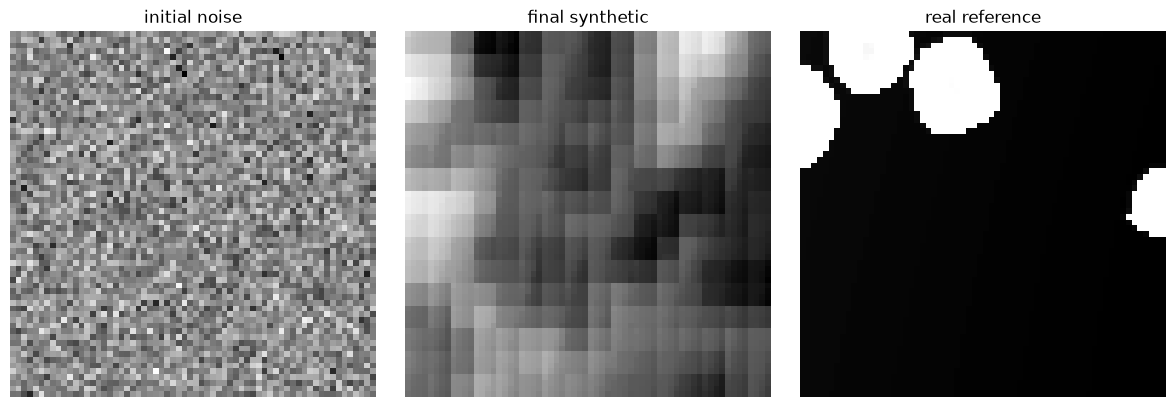

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, title, img in zip(axes, ["initial noise", "final synthetic", "real reference"], [history[0], final_image, clean_ref]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Intermediate steps: coarse to fine

Showing a few snapshots across the run makes the "denoise a little, add a
little less noise, repeat" process visible rather than just the before/after.

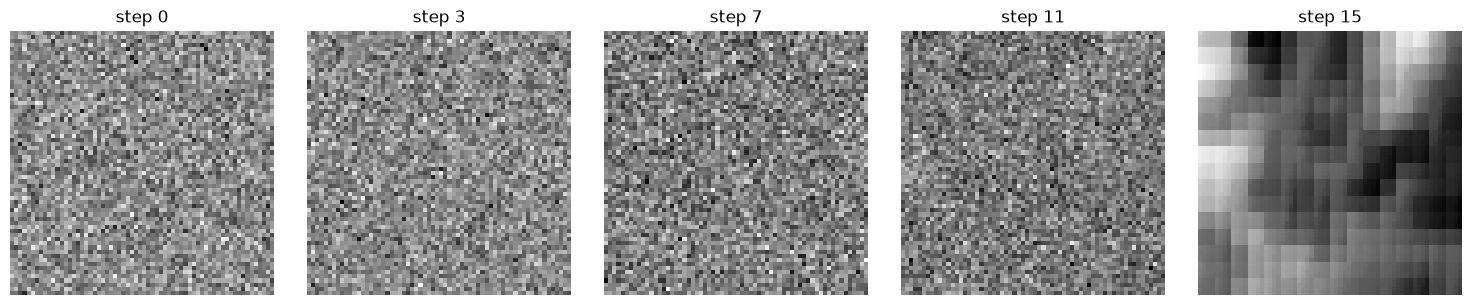

In [5]:
num_show = 5
show_indices = np.linspace(0, len(history) - 1, num_show).astype(int)

fig, axes = plt.subplots(1, num_show, figsize=(3 * num_show, 3))
for ax, idx in zip(axes, show_indices):
    ax.imshow(history[idx], cmap="gray")
    ax.set_title(f"step {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Finding: variance collapse (negative result)

The sampler runs end-to-end without crashing, but the outcome is a genuine
failure worth recording, not a success to gloss over.

In [6]:
print(f"real NIST crop std: {clean_ref.std():.1f}")
print(f"initial noise std:      {history[0].std():.1f}")
print(f"final synthetic std:    {final_image.std():.1f}")


real NIST crop std: 55.6
initial noise std:      23.8
final synthetic std:    0.8


**What happened:** std drops from the source image's ~55 toward under 1
within just a few steps - even after calibrating sigma from the bank's own
distance distribution (ruling out "wrong hardcoded constant" as the cause).
Cutting the step count from 15 down to 3 still collapses to std ~0.4-0.7.
The collapse is immediate, not a slow accumulation over many iterations.

**Why:** `denoise_patch` computes a similarity-weighted *average* of bank
patches. Averaging is a variance-reducing operation by construction - the
result is always smoother than any individual patch that went into it. That
is exactly correct behavior for denoising a real noisy photo (you want the
stable, de-noised estimate). It is the wrong behavior for *generation*,
where the goal is a plausible sample with realistic variance, not the
smoothed mean. Re-adding noise between steps at the next sigma does not
compensate for this, because it adds *unstructured* variance while the
denoiser keeps removing *structured* variance - the two are not equal and
opposite.

**Why we are not patching this with a bigger noise term:** the correct fix
is the reverse-process update the method's underlying theory specifies,
which corrects for exactly this shrinkage - not a hand-tuned constant that
would only work for this one image and step count. Getting that update
right belongs with the coarse-to-fine sampler, not as a quick patch here.

**Status:** the single-scale sampler is verified to run correctly end-to-end
(no crash, deterministic, calibrates itself to any bank) and its failure
mode is measured and understood, but it does not yet produce texture-
preserving output. This is a documented limitation carried forward, not a
blocker treated as invisible.
